In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import datasets, layers, models

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
train_images, test_images = train_images/255.0, test_images/255.0

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
from keras.models import Sequential

In [7]:
model = Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 60ms/step - accuracy: 0.4402 - loss: 1.5334 - val_accuracy: 0.5521 - val_loss: 1.2459
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.5880 - loss: 1.1628 - val_accuracy: 0.6044 - val_loss: 1.1300
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 60ms/step - accuracy: 0.6454 - loss: 1.0091 - val_accuracy: 0.6371 - val_loss: 1.0325
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.6793 - loss: 0.9089 - val_accuracy: 0.6705 - val_loss: 0.9381
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.7101 - loss: 0.8300 - val_accuracy: 0.6732 - val_loss: 0.9266
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7318 - loss: 0.7682 - val_accuracy: 0.6930 - val_loss: 0.9029
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7470 - loss: 0.7191 - val_accuracy: 0.6846 - val_loss: 0.9383
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.7650 -

In [10]:
print("Training Accuracy: ", history.history['accuracy'][-1])
print("Validation Accuracy: ", history.history['val_accuracy'][-1])

Training Accuracy:  0.790880024433136
Validation Accuracy:  0.7116000056266785


In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7116 - loss: 0.8658
Test Accuracy: 0.7116000056266785


In [12]:
import numpy as np
import matplotlib.pyplot as plt

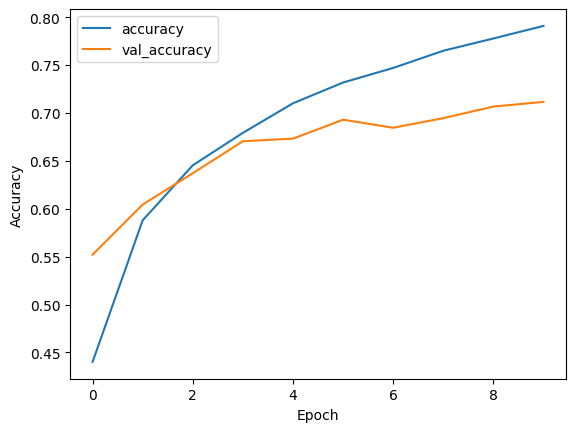

In [13]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


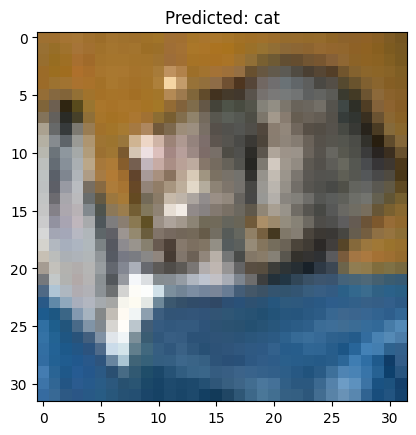

In [18]:
pred = model.predict(test_images)
plt.imshow(test_images[0])
plt.title(f"Actual: {class_names[test_labels[0][0]]}")
plt.title(f"Predicted: {class_names[np.argmax(pred[0])]}")
plt.show()

# plt.imshow(test_images[1])
# plt.title(f"Actual: {class_names[test_labels[1][0]]}")
# plt.title(f"Predicted: {class_names[np.argmax(pred[1])]}")
# plt.show()